# 02. LROM Method Walkthrough

This notebook walks through the learned reduced-operator model (LROM)
idea in stages:

1. one-parameter linear LROM for the Woods-Saxon depth `Vv`,
2. one-parameter linear LROM for the radius `Rv`,
3. a small multiparameter example using potential predictors.

The target coordinates are always the least-squares (LS) projection of
FOM wavefunctions onto the chosen reduced basis.  This lets us separate
basis error from reduced-equation error.

In the one-parameter coefficient plots below we use an **absolute**
coefficient error, not a relative coefficient error.  At the central
parameter point the target coefficient vector is close to zero by
construction, so a relative error can artificially blow up even when
the absolute coefficient mismatch and reconstructed wavefunction error
are tiny.

The one-parameter examples also keep the wavefunctions in their raw
normalization.  ROSE often rescales snapshots internally before building
a basis, which is useful numerically but changes the apparent magnitude
of the reduced coefficients.  Here we leave the snapshots unscaled so
the coordinate sizes are easier to interpret.

In [1]:
from pathlib import Path
import importlib
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "lrom_demo").exists() and (ROOT.parent / "lrom_demo").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUT = ROOT / "outputs" / Path(__file__).stem if "__file__" in globals() else ROOT / "outputs" / "notebook_outputs"
OUT.mkdir(parents=True, exist_ok=True)

import rose
from lrom_demo import rose_rom
rose_rom = importlib.reload(rose_rom)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

print("ROSE imported from:", rose.__file__)
print("output folder:", OUT)

ROSE imported from: /home/pablo/.local/lib/python3.10/site-packages/rose/__init__.py
output folder: /home/pablo/research-projects/new-project-3/clean_lrom_demo/outputs/notebook_outputs


In [2]:
from lrom_demo import core
from lrom_demo import simple_lrom as slrom

## Helper Plot

The central parameter point is omitted from the log-error plots.  In the
central formulation we enforce \(a(lpha_c)=0\), so that point is often
reproduced at machine precision.  Showing it mostly sets the vertical
scale, instead of revealing interpolation and extrapolation behavior.

Coefficient plots are only meaningful when the curves live in the same
reduced coordinate system.  The left column below uses standard ROSE
coordinates built with ROSE's free-solution reference state.  The middle
column uses central LROM coordinates built with
\(\phi_0=\phi(lpha_c)\).  These are different coordinate systems, so
the right column compares each emulator only against its own LS target
coefficients.

In [3]:
_LOG_TINY = 1e-300
PLOT_CLIP_FLOOR = 1e-11


def positive_for_log(values):
    values = np.asarray(values, dtype=float)
    return np.clip(values, _LOG_TINY, None)


def visible_log_ylim(arrays, min_visible=PLOT_CLIP_FLOOR, low_quantile=0.03, pad=3.0):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        arr = arr[np.isfinite(arr) & (arr > min_visible)]
        if arr.size:
            vals.append(arr)
    if not vals:
        for arr in arrays:
            arr = np.asarray(arr, dtype=float)
            arr = arr[np.isfinite(arr) & (arr > 0)]
            if arr.size:
                vals.append(arr)
    if not vals:
        return min_visible, 1.0
    vals = np.concatenate(vals)
    lo = max(min_visible, float(np.quantile(vals, low_quantile)) / pad)
    hi = max(float(np.max(vals)) * pad, lo * 100)
    return lo, hi


def visible_linear_ylim(arrays, low_quantile=0.04, high_quantile=0.96, pad_fraction=0.12):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size:
            vals.append(arr)
    if not vals:
        return -1.0, 1.0
    vals = np.concatenate(vals)
    lo = float(np.quantile(vals, low_quantile))
    hi = float(np.quantile(vals, high_quantile))
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        center = float(np.mean(vals)) if vals.size else 0.0
        return center - 1.0, center + 1.0
    span = hi - lo
    return lo - pad_fraction * span, hi + pad_fraction * span


def plot_real_ws_rainbow(dataset, title):
    values = np.asarray(dataset.test_values, dtype=float)
    order = np.argsort(values)
    colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(order)))
    r = dataset.r_mesh

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
    for color, idx in zip(colors, order):
        alpha = dataset.test_alphas[idx]
        phi = np.real_if_close(dataset.phi_hf_test[idx]).real
        V = np.array([core.real_volume_woods_saxon(float(ri), alpha) for ri in r])
        axes[0].plot(r, phi, color=color, lw=1.5, alpha=0.85)
        axes[1].plot(r, V, color=color, lw=1.5, alpha=0.85)

    axes[0].set_title("FOM wavefunctions")
    axes[0].set_xlabel("r [fm]")
    axes[0].set_ylabel(r"$\phi_{\rm FOM}(r)$")
    axes[0].set_xlim(0, min(22, float(r[-1])))

    axes[1].set_title("real Woods-Saxon potential")
    axes[1].set_xlabel("r [fm]")
    axes[1].set_ylabel(r"$V(r)$ [MeV]")
    axes[1].set_xlim(0, min(14, float(r[-1])))

    sm = plt.cm.ScalarMappable(
        cmap="viridis",
        norm=plt.Normalize(vmin=float(values.min()), vmax=float(values.max())),
    )
    sm.set_array([])
    fig.colorbar(sm, ax=axes, label=dataset.name, shrink=0.85)
    fig.suptitle(title)
    fig.tight_layout()
    return fig


def plot_one_parameter_result(rose_dataset, central_dataset, predictors_train, predictors_test, title):
    fit = slrom.fit_central_lrom(title, predictors_train, central_dataset.coeff_train)
    coeff_pred = slrom.predict_coefficients(fit, predictors_test)
    phi_pred = slrom.reconstruct_from_basis(central_dataset.rbe.basis, coeff_pred)
    lrom_wf_err = slrom.relative_l2_rows(phi_pred, central_dataset.phi_basis_test)
    rose_wf_err = slrom.relative_l2_rows(rose_dataset.phi_rbm_test, rose_dataset.phi_basis_test)
    rose_ls_phi = slrom.reconstruct_from_basis(rose_dataset.rbe.basis, rose_dataset.coeff_test)
    lrom_ls_phi = slrom.reconstruct_from_basis(central_dataset.rbe.basis, central_dataset.coeff_test)
    rose_ls_wf_err = slrom.relative_l2_rows(rose_ls_phi, rose_dataset.phi_basis_test)
    lrom_ls_wf_err = slrom.relative_l2_rows(lrom_ls_phi, central_dataset.phi_basis_test)

    x = central_dataset.test_values
    rose_target = rose_dataset.coeff_test
    rose_pred = rose_dataset.coeff_rom_test
    central_target = central_dataset.coeff_test
    lrom = coeff_pred
    n_rose = rose_target.shape[1]
    n_lrom = central_target.shape[1]
    n_u_rose = getattr(getattr(rose_dataset, "rbe", None), "n_U", 8)
    k_lrom = fit.n_predictors
    n_show = min(4, rose_target.shape[1], central_target.shape[1])
    colors = plt.cm.tab10(np.arange(n_show))
    rose_abs_err = np.abs(rose_pred[:, :n_show] - rose_target[:, :n_show])
    lrom_abs_err = np.abs(lrom[:, :n_show] - central_target[:, :n_show])
    err_ylim = visible_log_ylim([rose_abs_err, lrom_abs_err])
    wf_ylim = visible_log_ylim([lrom_wf_err, rose_wf_err, rose_ls_wf_err, lrom_ls_wf_err])
    train_min = float(np.min(central_dataset.train_values))
    train_max = float(np.max(central_dataset.train_values))

    def mark_training_window(ax):
        ax.axvspan(train_min, train_max, color="0.9", zorder=-10)
        ax.axvline(train_min, color="0.5", lw=1, ls="--")
        ax.axvline(train_max, color="0.5", lw=1, ls="--")
        y = 0.96
        ax.text(0.02, y, "extrapolation", transform=ax.transAxes,
                ha="left", va="top", fontsize=8, color="0.35")
        ax.text(0.98, y, "extrapolation", transform=ax.transAxes,
                ha="right", va="top", fontsize=8, color="0.35")

    coeff_fig, axes = plt.subplots(n_show, 3, figsize=(13.5, 2.25 * n_show), sharex="col")
    if n_show == 1:
        axes = axes[np.newaxis, :]
    for i in range(n_show):
        ax = axes[i, 0]
        ax.plot(x, rose_target[:, i].real, color=colors[i], lw=2, label=fr"ROSE LS $a_{i+1}$")
        ax.plot(x, rose_pred[:, i].real, "--", color=colors[i], lw=2, label=fr"ROSE $a_{i+1}$")
        mark_training_window(ax)
        ax.set_ylabel(fr"$a_{i+1}$")
        if i == 0:
            ax.set_title("ROSE free-reference coefficients")
            ax.legend(fontsize=8)

        ax = axes[i, 1]
        ax.plot(x, central_target[:, i].real, color=colors[i], lw=2, label=fr"central LS $a_{i+1}$")
        ax.plot(x, lrom[:, i].real, ":", color=colors[i], lw=2.5, label=fr"LROM $a_{i+1}$")
        mark_training_window(ax)
        if i == 0:
            ax.set_title("Central-basis LS coefficients + LROM")
            ax.legend(fontsize=8)

        ax = axes[i, 2]
        ax.semilogy(x, positive_for_log(rose_abs_err[:, i]),
                    "--", color=colors[i], lw=2, label="ROSE vs ROSE LS")
        ax.semilogy(x, positive_for_log(lrom_abs_err[:, i]),
                    ":", color=colors[i], lw=2.5, label="LROM vs central LS")
        mark_training_window(ax)
        ax.set_ylim(*err_ylim)
        ax.set_ylabel(fr"$|\Delta a_{i+1}|$")
        if i == 0:
            ax.set_title("Absolute coefficient differences")
            ax.legend(fontsize=8)
    for ax in axes[-1, :]:
        ax.set_xlabel(central_dataset.name)
    coeff_fig.suptitle(title + ": reduced-coordinate diagnostics")
    coeff_fig.tight_layout()

    wf_fig, ax = plt.subplots(1, 1, figsize=(6.5, 3.7))
    ax.semilogy(x, positive_for_log(rose_ls_wf_err), "--", color="black", lw=2,
                label=fr"ROSE LS floor ($n={n_rose}$)")
    ax.semilogy(x, positive_for_log(lrom_ls_wf_err), "--", color="0.55", lw=2,
                label=fr"LROM LS floor ($n={n_lrom}$)")
    ax.semilogy(x, positive_for_log(lrom_wf_err), "o-",
                label=fr"LROM ($n={n_lrom}, K={k_lrom}$)")
    ax.semilogy(x, positive_for_log(rose_wf_err), "s--",
                label=fr"ROSE ROM ($n={n_rose}, n_U={n_u_rose}$)")
    mark_training_window(ax)
    ax.set_ylim(*wf_ylim)
    ax.set_xlabel(central_dataset.name)
    ax.set_ylabel(r"$\|\phi_{\rm FOM}-\hat{\phi}\|_2 / \|\phi_{\rm FOM}\|_2$")
    ax.set_title("Wavefunction error")
    ax.legend()
    wf_fig.tight_layout()
    return fit, coeff_fig, wf_fig


def plot_scan_coefficients_and_errors(data, coeff_predictions, prediction_labels, scan_info, title, out_prefix):
    # Plot coefficient trajectories and absolute coefficient errors along one-at-a-time scans.

    n_show = min(4, data.coeff_test.shape[1])
    colors = plt.cm.tab10(np.arange(n_show))

    coeff_fig, axes = plt.subplots(len(scan_info), n_show, figsize=(3.2 * n_show, 2.6 * len(scan_info)), sharex=False)
    if len(scan_info) == 1:
        axes = axes[np.newaxis, :]
    for row, (scan_name, vals, slc) in enumerate(scan_info):
        target = data.coeff_test[slc]
        for j in range(n_show):
            ax = axes[row, j]
            ax.plot(vals, target[:, j].real, color="black", lw=2, label="LS target")
            y_curves = [target[:, j].real]
            for pred, label, style in coeff_predictions:
                ax.plot(vals, pred[slc, j].real, style, lw=2, label=label)
                y_curves.append(pred[slc, j].real)
            ax.axvline(data.central_sample[{"Vv": 0, "Rv": 1, "av": 2}[scan_name]], color="0.35", lw=1)
            ax.axvspan(
                data.central_sample[{"Vv": 0, "Rv": 1, "av": 2}[scan_name]] - data.feature_scales[{"Vv": 0, "Rv": 1, "av": 2}[scan_name]],
                data.central_sample[{"Vv": 0, "Rv": 1, "av": 2}[scan_name]] + data.feature_scales[{"Vv": 0, "Rv": 1, "av": 2}[scan_name]],
                color="0.9",
                zorder=-10,
            )
            ax.set_ylim(*visible_linear_ylim(y_curves))
            if row == 0:
                ax.set_title(fr"$a_{j + 1}$")
            if j == 0:
                ax.set_ylabel(r"$\mathrm{Re}\,a_j$")
            if row == len(scan_info) - 1:
                ax.set_xlabel(scan_name)
            if row == 0 and j == 0:
                ax.legend(fontsize=7)
    coeff_fig.suptitle(title + ": coefficient trajectories")
    coeff_fig.tight_layout()
    coeff_fig.savefig(OUT / f"{out_prefix}_coefficients.png", dpi=180, bbox_inches="tight")

    err_fig, axes = plt.subplots(len(scan_info), n_show, figsize=(3.2 * n_show, 2.6 * len(scan_info)), sharex=False)
    if len(scan_info) == 1:
        axes = axes[np.newaxis, :]
    for row, (scan_name, vals, slc) in enumerate(scan_info):
        target = data.coeff_test[slc]
        cidx = {"Vv": 0, "Rv": 1, "av": 2}[scan_name]
        center_value = data.central_sample[cidx]
        scan_width = max(float(np.max(vals) - np.min(vals)), 1.0)
        noncentral = np.abs(vals - center_value) > 0.02 * scan_width
        for j in range(n_show):
            ax = axes[row, j]
            err_curves = []
            for pred, label, style in coeff_predictions:
                err = np.abs(pred[slc, j] - target[:, j])
                err_curves.append((err, label, style))
            err_ylim = visible_log_ylim(
                [err[noncentral] for err, _, _ in err_curves],
                min_visible=1e-7,
            )
            for err, label, style in err_curves:
                ax.semilogy(vals, positive_for_log(err), style, lw=2, label=label)
            ax.axvline(center_value, color="0.35", lw=1)
            ax.axvspan(
                center_value - data.feature_scales[cidx],
                center_value + data.feature_scales[cidx],
                color="0.9",
                zorder=-10,
            )
            ax.set_ylim(*err_ylim)
            if row == 0:
                ax.set_title(fr"$|\Delta a_{j + 1}|$")
            if j == 0:
                ax.set_ylabel(r"$|\Delta a_j|$")
            if row == len(scan_info) - 1:
                ax.set_xlabel(scan_name)
            if row == 0 and j == 0:
                ax.legend(fontsize=7)
    err_fig.suptitle(title + ": coefficient errors")
    err_fig.tight_layout()
    err_fig.savefig(OUT / f"{out_prefix}_coefficient_errors.png", dpi=180, bbox_inches="tight")
    return coeff_fig, err_fig


def plot_scan_error_curves(data, error_curves, scan_info, title, out_prefix):
    # Plot already-computed error arrays. This lets us compare methods
    # whose coefficients live in different reduced bases.

    fig, axes = plt.subplots(1, len(scan_info), figsize=(4.3 * len(scan_info), 3.4), sharey=True)
    if len(scan_info) == 1:
        axes = [axes]
    for ax, (scan_name, vals, slc) in zip(axes, scan_info):
        cidx = {"Vv": 0, "Rv": 1, "av": 2}[scan_name]
        center_value = data.central_sample[cidx]
        scan_width = max(float(np.max(vals) - np.min(vals)), 1.0)
        noncentral = np.abs(vals - center_value) > 0.02 * scan_width
        ylim = visible_log_ylim(
            [curve[0][slc][noncentral] for curve in error_curves],
            min_visible=1e-7,
        )
        for curve in error_curves:
            if len(curve) == 4:
                err, label, style, color = curve
            else:
                err, label, style = curve
                color = None
            ax.semilogy(vals, positive_for_log(err[slc]), style, color=color, lw=2, label=label)
        ax.axvline(center_value, color="0.35", lw=1)
        ax.axvspan(
            center_value - data.feature_scales[cidx],
            center_value + data.feature_scales[cidx],
            color="0.9",
            zorder=-10,
        )
        ax.set_ylim(*ylim)
        ax.set_xlabel(scan_name)
        ax.set_title(scan_name)
        ax.legend(fontsize=8)
    axes[0].set_ylabel(r"$\|\phi_{\rm FOM}-\hat{\phi}\|_2 / \|\phi_{\rm FOM}\|_2$")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(OUT / f"{out_prefix}_wavefunction_errors.png", dpi=180, bbox_inches="tight")
    return fig


def plot_predictor_points_on_potential(interaction, central_alpha, rho_mesh, pack, title):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    U0 = np.real_if_close(interaction.tilde(rho_mesh, central_alpha)).real
    Up = np.real_if_close(interaction.tilde(pack.s_points, central_alpha)).real
    ax.plot(rho_mesh, U0, color="black", lw=2, label=r"central $U(s)$")
    ax.scatter(pack.s_points, Up, s=55, color="crimson", zorder=5, label="delta-maxvol predictors")
    for s in pack.s_points:
        ax.axvline(s, color="crimson", lw=0.8, alpha=0.35)
    ax.set_xlim(0, min(12, float(rho_mesh[-1])))
    ax.set_xlabel("operator coordinate s")
    ax.set_ylabel(r"scaled potential $U(s)$")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    return fig


def plot_predictor_rainbows(interaction, central_alpha, rho_mesh, pack, scan_info, test_alphas, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=False)
    wanted = ["Vv", "Rv"]
    for ax, scan_name in zip(axes, wanted):
        vals, slc = next((vals, slc) for name, vals, slc in scan_info if name == scan_name)
        colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(vals)))
        y_values = []
        for color, alpha in zip(colors, test_alphas[slc]):
            U = np.real_if_close(interaction.tilde(rho_mesh, alpha)).real
            y_values.append(U)
            ax.plot(rho_mesh, U, color=color, lw=1.3, alpha=0.85)
        Uc = np.real_if_close(interaction.tilde(pack.s_points, central_alpha)).real
        y_values.append(Uc)
        ax.scatter(pack.s_points, Uc, color="crimson", s=45, zorder=5, label="predictor points")
        for s in pack.s_points:
            ax.axvline(s, color="crimson", lw=0.8, alpha=0.25)
        ax.set_xlim(0, min(12, float(rho_mesh[-1])))
        ax.set_ylim(*visible_linear_ylim(y_values, low_quantile=0.01, high_quantile=0.99, pad_fraction=0.08))
        ax.set_xlabel("operator coordinate s")
        ax.set_title(f"rainbow in {scan_name}")
        sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=float(vals.min()), vmax=float(vals.max())))
        sm.set_array([])
        fig.colorbar(sm, ax=ax, label=scan_name, shrink=0.85)
        ax.legend(fontsize=8)
    axes[0].set_ylabel(r"scaled potential $U(s)$")
    fig.suptitle(title)
    fig.tight_layout()
    return fig


def plot_predictor_values_vs_parameters(interaction, central_alpha, pack, scan_info, test_alphas, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.7), sharey=True)
    wanted = ["Vv", "Rv"]
    for ax, scan_name in zip(axes, wanted):
        vals, slc = next((vals, slc) for name, vals, slc in scan_info if name == scan_name)
        P = slrom.centered_potential_predictors(interaction, test_alphas[slc], pack).real
        for j in range(P.shape[1]):
            ax.plot(vals, P[:, j], lw=1.8, label=fr"$p_{j+1}$")
        ax.axvline(central_alpha[{"Vv": 0, "Rv": 1}[scan_name]], color="0.35", lw=1)
        ax.set_xlabel(scan_name)
        ax.set_title(f"predictors vs {scan_name}")
    axes[0].set_ylabel(r"centered predictor value $p_j(\alpha)$")
    axes[0].legend(ncol=2, fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    return fig

## Varying Only The Real Volume Depth

For these one-parameter teaching examples we deliberately use a stripped
down real interaction,
\[
    V(r)=-V_v f_{m WS}(r;R_v,a_v),
\]
with no imaginary volume term, no surface absorption, and no spin-orbit
term.  This keeps the reduced coordinates essentially real and lets us
focus on the LROM algebra.

With central formulation, the equation is

\[
(I + \Delta V_v M_V)a = \Delta V_v b_V .
\]

Because changing `Vv` mainly rescales a fixed radial shape, this is the
cleanest case for the LROM.

  0%|          | 0/2 [00:00<?, ?it/s]

 50%|█████     | 1/2 [00:02<00:02,  2.17s/it]

100%|██████████| 2/2 [00:03<00:00,  1.83s/it]

100%|██████████| 2/2 [00:03<00:00,  1.88s/it]

/tmp/ipykernel_12672/2383680282.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


raw central LS coefficient ranges and max emulator differences:
  a1: LS range [-1.254e+01,  1.100e+01], max |LROM-LS|=3.896e-03, max |ROSE-ROSE LS|=1.826e-01
  a2: LS range [-7.068e+00,  1.187e-14], max |LROM-LS|=4.290e-03, max |ROSE-ROSE LS|=3.865e-01
  a3: LS range [-1.764e-01,  2.862e-01], max |LROM-LS|=2.065e-04, max |ROSE-ROSE LS|=6.331e-02
  a4: LS range [-4.208e-02,  3.081e-05], max |LROM-LS|=1.713e-03, max |ROSE-ROSE LS|=2.992e-02


CentralLROM(name='Linear LROM: varying Vv', matrices=array([[[ 2.59130793e-02+0.j, -1.09194469e-01+0.j, -9.68491162e-02+0.j,
         -7.14807450e-01+0.j],
        [ 1.32554395e-01+0.j,  2.37548174e-02+0.j, -7.48565984e-01+0.j,
         -2.84775539e-02+0.j],
        [-2.72135003e-06+0.j, -1.10309503e-02+0.j,  2.28081659e-02+0.j,
         -2.29367725e-02+0.j],
        [-6.78496311e-06+0.j, -2.52654028e-05+0.j, -3.82389387e-02+0.j,
          2.11331966e-02+0.j]]]), vectors=array([[ 4.03189671e+00+0.j, -2.54377973e-02+0.j,  3.69842712e-03+0.j,
         9.76827679e-06+0.j]]), train_seconds=0.00014434200420510024, residual_mse=1.279690085448252e-15, rank=20, singular_values=array([1.11754897e+01, 1.11754897e+01, 1.11754897e+01, 1.11754897e+01,
       3.71051562e+00, 3.71051562e+00, 3.71051562e+00, 3.71051562e+00,
       4.85767435e-01, 4.85767435e-01, 4.85767435e-01, 4.85767435e-01,
       3.65149376e-03, 3.65149376e-03, 3.65149376e-03, 3.65149376e-03,
       5.73694022e-05, 5.73694022e-05,

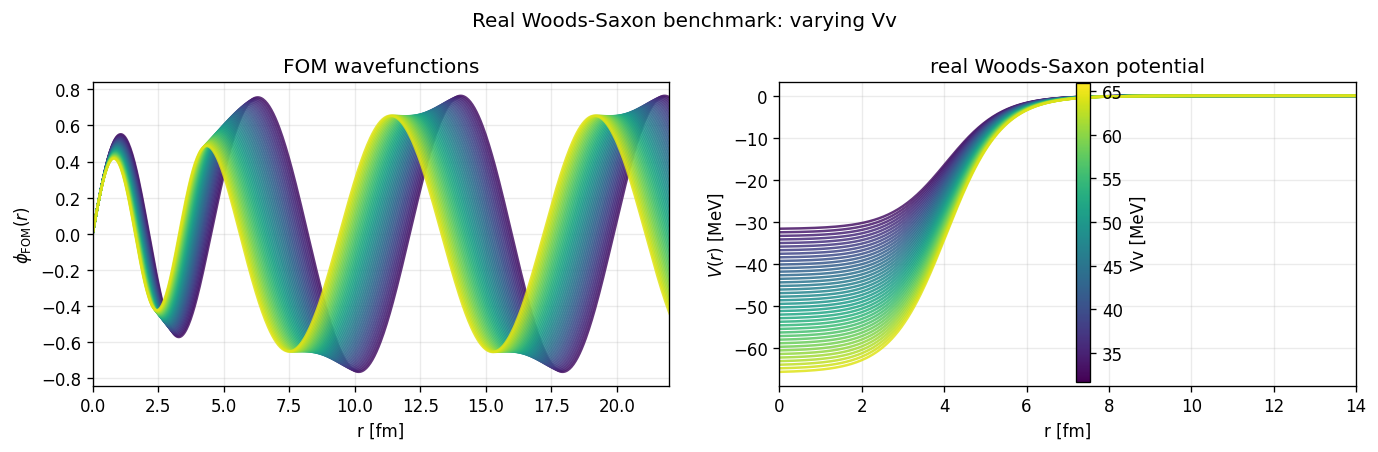

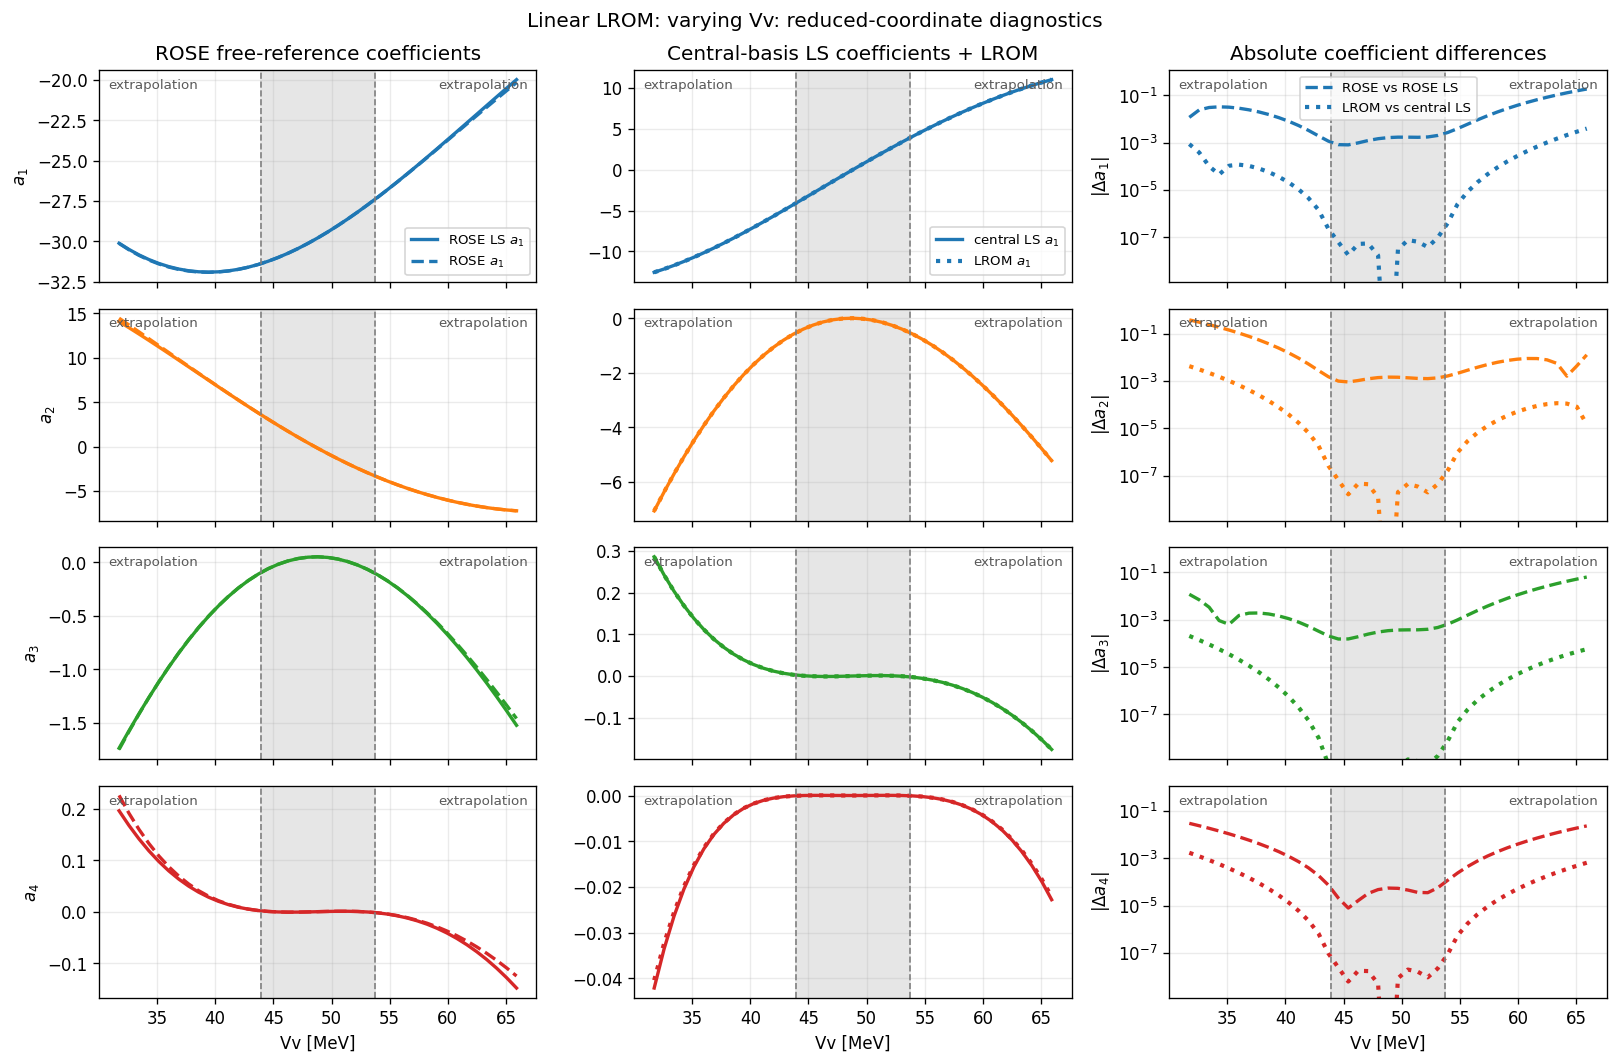

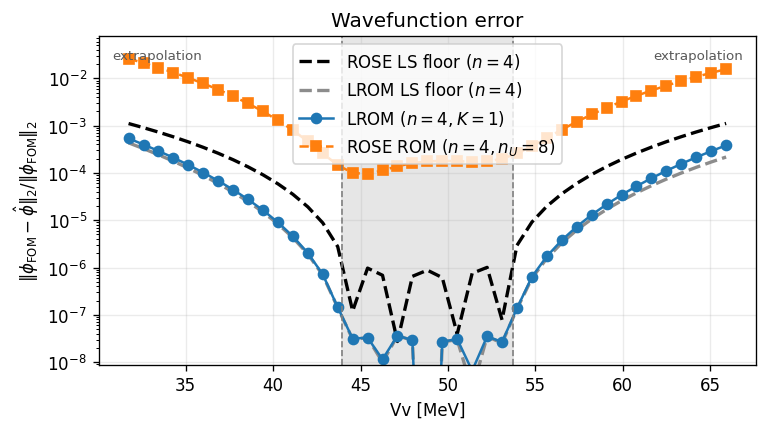

In [4]:
*_unused, alpha0 = core.central_real_ws_parameters()
V0 = alpha0[0]
vv_train = np.linspace(0.90 * V0, 1.10 * V0, 35)
vv_test = np.linspace(0.65 * V0, 1.35 * V0, 41)

vv_rose_data = core.train_one_parameter_rbe(
    name="Vv [MeV]",
    param_index=0,
    train_values=vv_train,
    test_values=vv_test,
    n_phi=4,
    n_U=8,
    l_max=1,
    n_mesh=800,
    real_ws_only=True,
)
vv_data = core.train_one_parameter_central_rbe(
    name="Vv [MeV]",
    param_index=0,
    train_values=vv_train,
    test_values=vv_test,
    central_value=V0,
    n_phi=4,
    n_U=8,
    l_max=1,
    n_mesh=800,
    real_ws_only=True,
    scale_snapshots=False,
)
p_vv_train = ((vv_train - V0) / (0.10 * V0))[:, None]
p_vv_test = ((vv_test - V0) / (0.10 * V0))[:, None]
vv_rainbow_fig = plot_real_ws_rainbow(vv_data, "Real Woods-Saxon benchmark: varying Vv")
vv_rainbow_fig.savefig(OUT / "lrom_varying_vv_rainbow.png", dpi=180, bbox_inches="tight")
vv_fit, vv_coeff_fig, vv_wf_fig = plot_one_parameter_result(vv_rose_data, vv_data, p_vv_train, p_vv_test, "Linear LROM: varying Vv")
vv_coeff_fig.savefig(OUT / "lrom_varying_vv_coefficients.png", dpi=180, bbox_inches="tight")
vv_wf_fig.savefig(OUT / "lrom_varying_vv_wavefunction_error.png", dpi=180, bbox_inches="tight")
vv_coeff_pred = slrom.predict_coefficients(vv_fit, p_vv_test)
print("raw central LS coefficient ranges and max emulator differences:")
for i in range(min(4, vv_data.coeff_test.shape[1])):
    ls_i = vv_data.coeff_test[:, i].real
    lrom_err_i = np.max(np.abs(vv_coeff_pred[:, i] - vv_data.coeff_test[:, i]))
    rose_err_i = np.max(np.abs(vv_rose_data.coeff_rom_test[:, i] - vv_rose_data.coeff_test[:, i]))
    print(
        f"  a{i+1}: LS range [{ls_i.min(): .3e}, {ls_i.max(): .3e}], "
        f"max |LROM-LS|={lrom_err_i:.3e}, "
        f"max |ROSE-ROSE LS|={rose_err_i:.3e}"
    )
vv_fit

## Varying Only The Radius

A linear `Rv` LROM is still useful locally, but it is less physically
faithful over large ranges because changing the radius shifts the
Woods-Saxon surface.

  0%|          | 0/2 [00:00<?, ?it/s]

 50%|█████     | 1/2 [00:01<00:01,  1.62s/it]

100%|██████████| 2/2 [00:03<00:00,  1.60s/it]

100%|██████████| 2/2 [00:03<00:00,  1.60s/it]

/tmp/ipykernel_12672/2383680282.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


raw central LS coefficient ranges and max emulator differences:
  a1: LS range [-1.109e+01,  1.168e+01], max |LROM-LS|=1.141e-01, max |ROSE-ROSE LS|=5.602e-01
  a2: LS range [ 0.000e+00,  6.459e+00], max |LROM-LS|=2.967e-01, max |ROSE-ROSE LS|=4.210e-01
  a3: LS range [-7.452e-01,  6.340e-01], max |LROM-LS|=3.722e-02, max |ROSE-ROSE LS|=1.299e-01
  a4: LS range [-1.076e-05,  4.329e-02], max |LROM-LS|=3.098e-03, max |ROSE-ROSE LS|=1.107e-01


CentralLROM(name='Linear LROM: varying Rv', matrices=array([[[-7.38507879e-03+0.j,  1.68539295e-01+0.j, -1.55522791e-01+0.j,
         -6.43898002e+00+0.j],
        [-7.64786480e-02+0.j,  2.69150508e-02+0.j,  5.55839879e-01+0.j,
         -1.05081290e+00+0.j],
        [ 1.14618758e-05+0.j,  2.96532967e-02+0.j, -3.57324997e-02+0.j,
         -1.02626397e+00+0.j],
        [ 3.34629993e-06+0.j,  3.75068070e-06+0.j,  1.21731343e-02+0.j,
          1.10825324e-02+0.j]]]), vectors=array([[3.07661765e+00+0.j, 1.77970919e-03+0.j, 4.38871362e-03+0.j,
        4.79999105e-07+0.j]]), train_seconds=0.00019545300165191293, residual_mse=9.23431435272056e-14, rank=20, singular_values=array([8.53156427e+00, 8.53156427e+00, 8.53156427e+00, 8.53156427e+00,
       3.55315128e+00, 3.55315128e+00, 3.55315128e+00, 3.55315128e+00,
       2.24522100e-01, 2.24522100e-01, 2.24522100e-01, 2.24522100e-01,
       4.32161615e-03, 4.32161615e-03, 4.32161615e-03, 4.32161615e-03,
       2.14088931e-05, 2.14088931e-05, 2.14

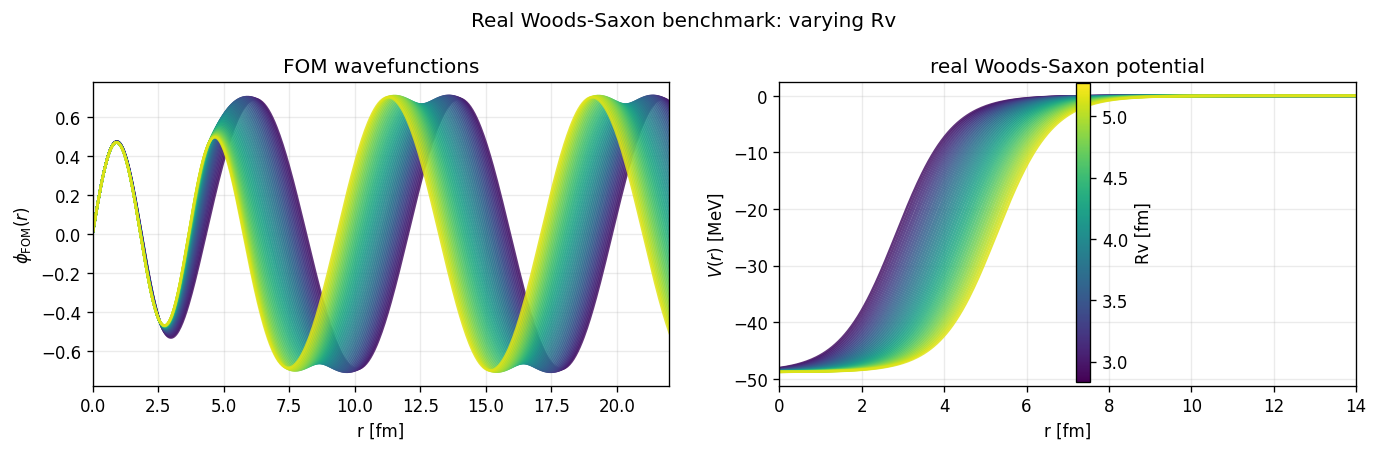

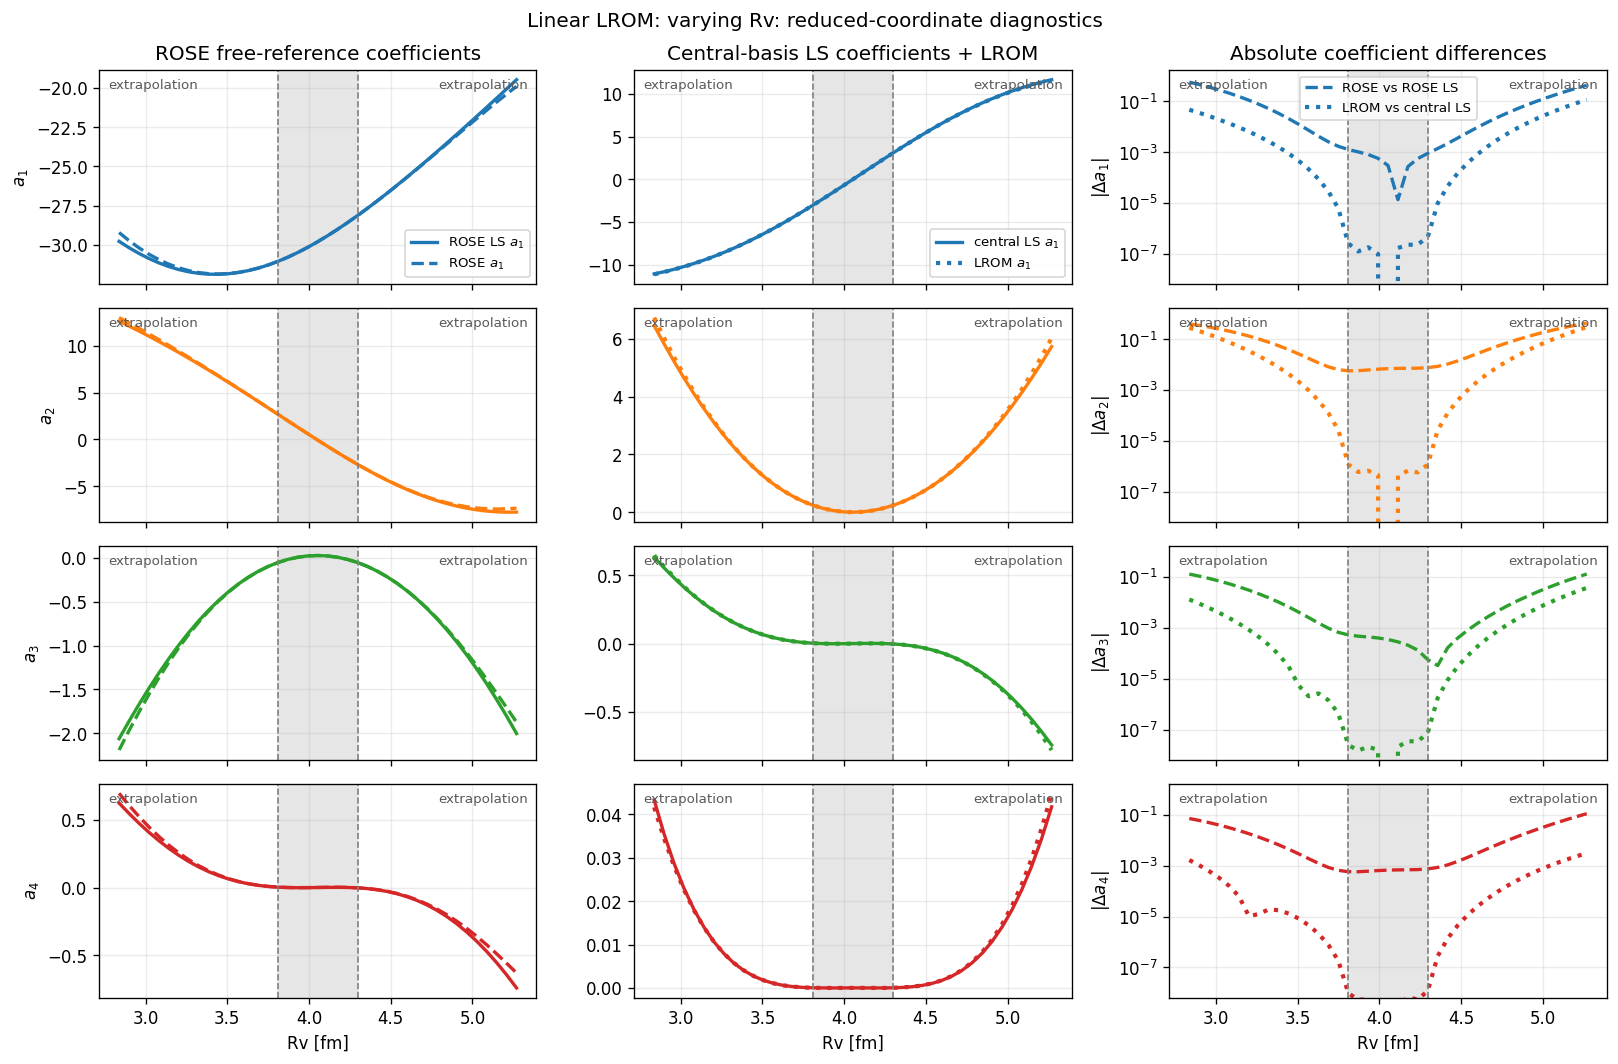

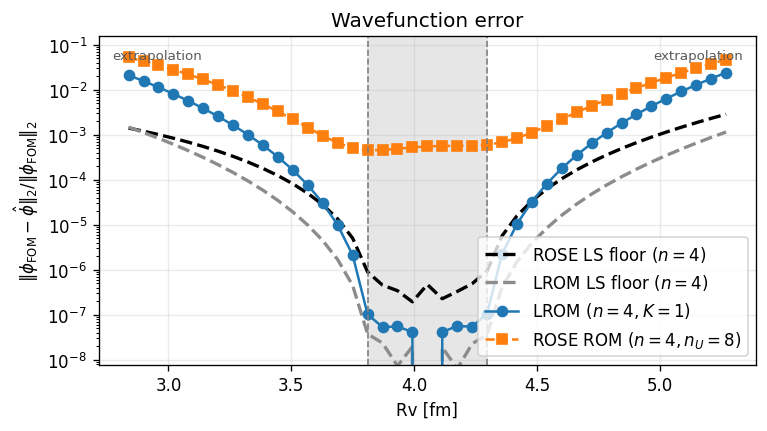

In [5]:
R0 = alpha0[1]
rv_train = np.linspace(0.94 * R0, 1.06 * R0, 35)
rv_test = np.linspace(0.70 * R0, 1.30 * R0, 41)

rv_rose_data = core.train_one_parameter_rbe(
    name="Rv [fm]",
    param_index=1,
    train_values=rv_train,
    test_values=rv_test,
    n_phi=4,
    n_U=8,
    l_max=1,
    n_mesh=800,
    real_ws_only=True,
)
rv_data = core.train_one_parameter_central_rbe(
    name="Rv [fm]",
    param_index=1,
    train_values=rv_train,
    test_values=rv_test,
    central_value=R0,
    n_phi=4,
    n_U=8,
    l_max=1,
    n_mesh=800,
    real_ws_only=True,
    scale_snapshots=False,
)
p_rv_train = ((rv_train - R0) / (0.06 * R0))[:, None]
p_rv_test = ((rv_test - R0) / (0.06 * R0))[:, None]
rv_rainbow_fig = plot_real_ws_rainbow(rv_data, "Real Woods-Saxon benchmark: varying Rv")
rv_rainbow_fig.savefig(OUT / "lrom_varying_rv_rainbow.png", dpi=180, bbox_inches="tight")
rv_fit, rv_coeff_fig, rv_wf_fig = plot_one_parameter_result(rv_rose_data, rv_data, p_rv_train, p_rv_test, "Linear LROM: varying Rv")
rv_coeff_fig.savefig(OUT / "lrom_varying_rv_coefficients.png", dpi=180, bbox_inches="tight")
rv_wf_fig.savefig(OUT / "lrom_varying_rv_wavefunction_error.png", dpi=180, bbox_inches="tight")
rv_coeff_pred = slrom.predict_coefficients(rv_fit, p_rv_test)
print("raw central LS coefficient ranges and max emulator differences:")
for i in range(min(4, rv_data.coeff_test.shape[1])):
    ls_i = rv_data.coeff_test[:, i].real
    lrom_err_i = np.max(np.abs(rv_coeff_pred[:, i] - rv_data.coeff_test[:, i]))
    rose_err_i = np.max(np.abs(rv_rose_data.coeff_rom_test[:, i] - rv_rose_data.coeff_test[:, i]))
    print(
        f"  a{i+1}: LS range [{ls_i.min(): .3e}, {ls_i.max(): .3e}], "
        f"max |LROM-LS|={lrom_err_i:.3e}, "
        f"max |ROSE-ROSE LS|={rose_err_i:.3e}"
    )
rv_fit

## Broad Vv/Rv Box: Where Linear Predictors Start To Struggle

The one-parameter tests are deliberately friendly.  Before introducing
potential predictors, it is useful to stress the simplest two-parameter
linear ansatz,

\[
\left(I+p_V M_V+p_R M_R\right)a=p_V b_V+p_R b_R .
\]

This model has independent directions for changing \(V_v\) and \(R_v\),
but no explicit cross terms.  Over a wider box, that becomes a real
limitation: changing \(R_v\) shifts the Woods-Saxon surface, and the
effect of changing \(V_v\) depends on where that surface is.  The plots
below show coefficient trajectories and coefficient errors along
one-at-a-time scans through the broad two-parameter box.

  0%|          | 0/2 [00:00<?, ?it/s]

 50%|█████     | 1/2 [00:02<00:02,  2.93s/it]

100%|██████████| 2/2 [00:05<00:00,  2.90s/it]

100%|██████████| 2/2 [00:05<00:00,  2.91s/it]

broad linear fit rank: 40 parameters: 40
median broad-scan WF error: 0.05173571561651652


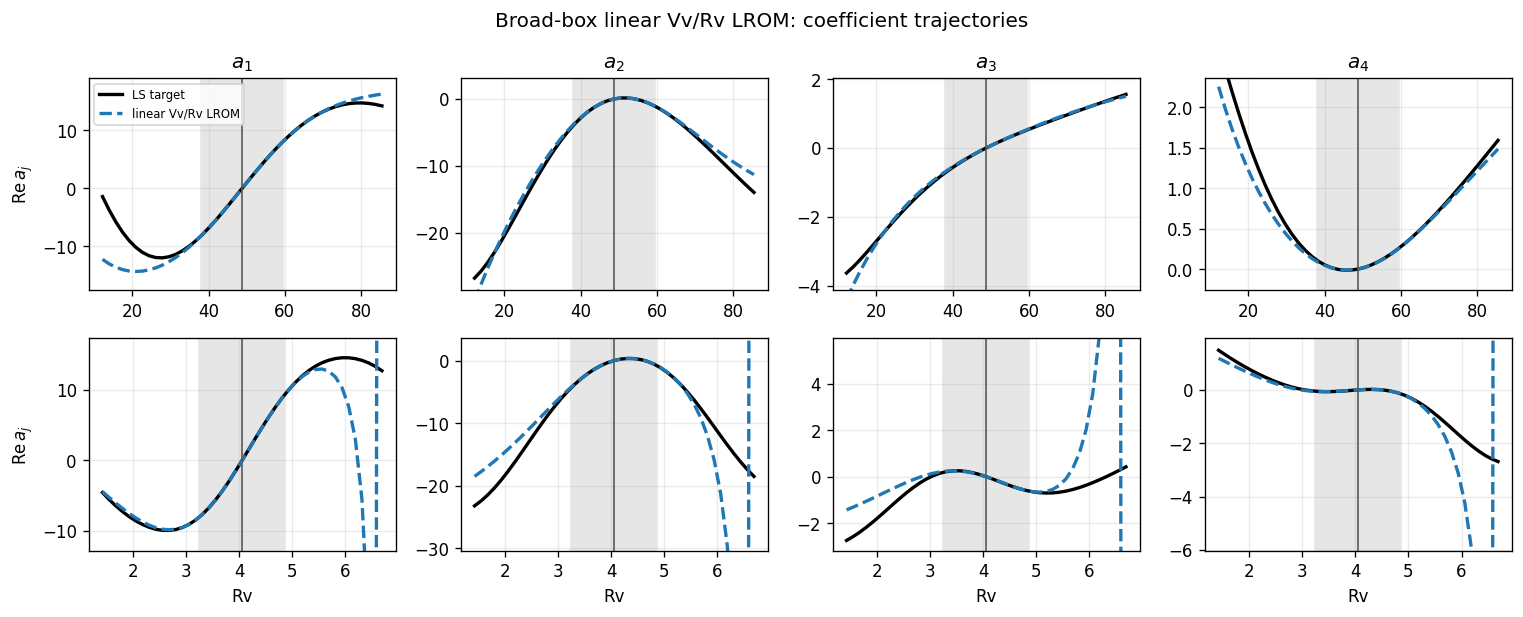

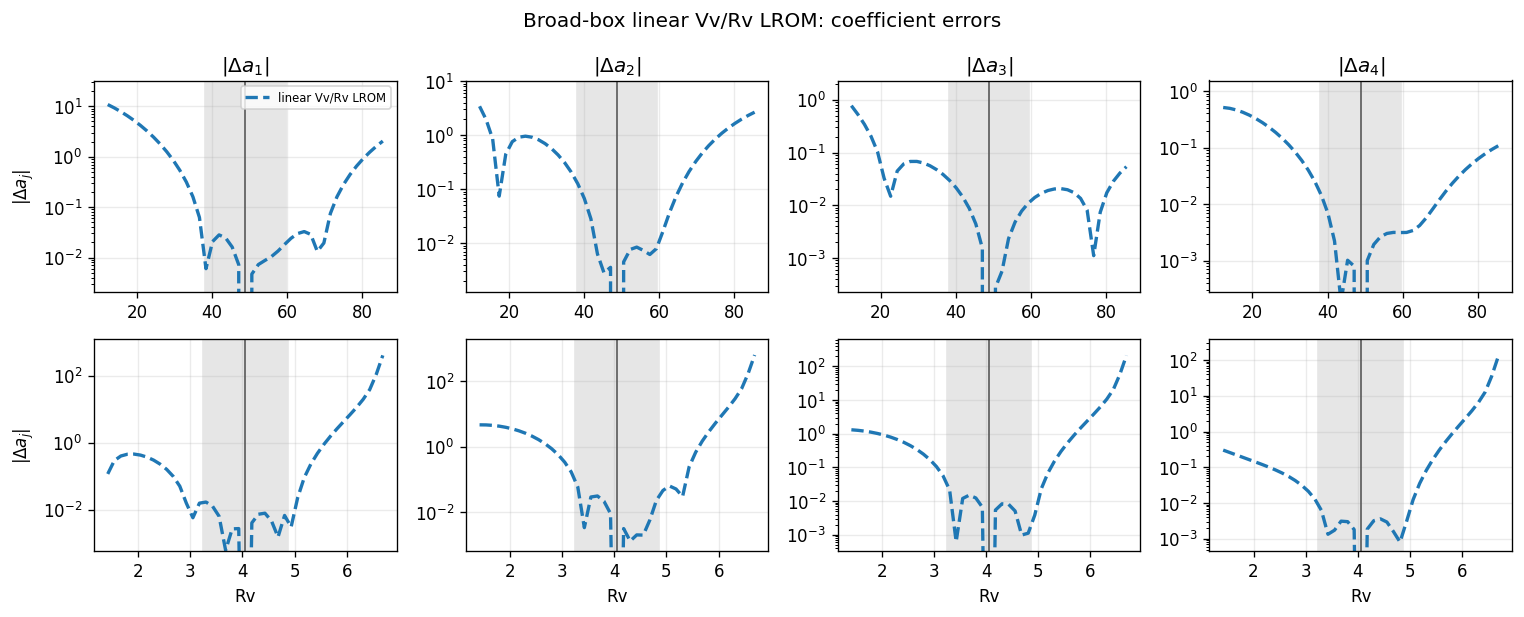

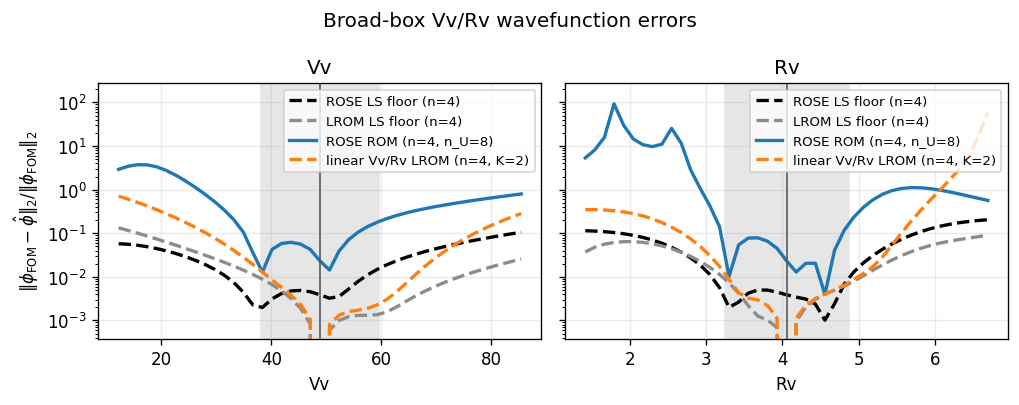

In [6]:
broad_center = np.array([V0, R0, alpha0[2], 14.1])
broad_scales = np.array([0.22 * V0, 0.20 * R0, 1.0, 1.0])
rng_broad = np.random.default_rng(1204)

broad_train = np.tile(broad_center, (70, 1))
broad_train[:, 0] += rng_broad.uniform(-1, 1, 70) * broad_scales[0]
broad_train[:, 1] += rng_broad.uniform(-1, 1, 70) * broad_scales[1]
broad_scan, broad_scan_info = slrom.one_at_a_time_scan_samples(
    broad_center,
    widths=np.array([0.75 * V0, 0.65 * R0, 0.0, 0.0]),
    n_scan=43,
    names=("Vv", "Rv"),
)

broad_rose_data = core.train_multiparameter_rbe(
    name="standard ROSE Vv/Rv broad box",
    train_samples=broad_train,
    test_samples=broad_scan,
    central_sample=broad_center,
    feature_scales=broad_scales,
    n_phi=4,
    n_U=8,
    l_max=1,
    n_mesh=800,
    real_ws_only=True,
)

broad_vr_data = core.train_multiparameter_central_rbe(
    name="broad Vv/Rv linear stress test",
    train_samples=broad_train,
    test_samples=broad_scan,
    central_sample=broad_center,
    feature_scales=broad_scales,
    n_phi=4,
    n_U=8,
    l_max=1,
    n_mesh=800,
    real_ws_only=True,
)

p_broad_train = slrom.centered_parameter_predictors(
    broad_train[:, :2],
    broad_center[:2],
    broad_scales[:2],
)
p_broad_scan = slrom.centered_parameter_predictors(
    broad_scan[:, :2],
    broad_center[:2],
    broad_scales[:2],
)
broad_linear_fit = slrom.fit_central_lrom("broad linear Vv/Rv LROM", p_broad_train, broad_vr_data.coeff_train)
broad_linear_coeff = slrom.predict_coefficients(broad_linear_fit, p_broad_scan)
broad_linear_phi = slrom.reconstruct_from_basis(broad_vr_data.rbe.basis, broad_linear_coeff)
broad_linear_wf_error = slrom.relative_l2_rows(broad_linear_phi, broad_vr_data.phi_basis_test)
broad_rose_wf_error = slrom.relative_l2_rows(broad_rose_data.phi_rbm_test, broad_rose_data.phi_basis_test)
broad_rose_ls_phi = slrom.reconstruct_from_basis(broad_rose_data.rbe.basis, broad_rose_data.coeff_test)
broad_lrom_ls_phi = slrom.reconstruct_from_basis(broad_vr_data.rbe.basis, broad_vr_data.coeff_test)
broad_rose_ls_wf_error = slrom.relative_l2_rows(broad_rose_ls_phi, broad_rose_data.phi_basis_test)
broad_lrom_ls_wf_error = slrom.relative_l2_rows(broad_lrom_ls_phi, broad_vr_data.phi_basis_test)

broad_coeff_fig, broad_err_fig = plot_scan_coefficients_and_errors(
    broad_vr_data,
    [(broad_linear_coeff, "linear Vv/Rv LROM", "--")],
    ["linear Vv/Rv LROM"],
    broad_scan_info,
    "Broad-box linear Vv/Rv LROM",
    "broad_linear_vv_rv",
)
print("broad linear fit rank:", broad_linear_fit.rank, "parameters:", broad_linear_fit.n_complex_parameters)
print("median broad-scan WF error:", np.median(broad_linear_wf_error))
display(broad_coeff_fig)
display(broad_err_fig)
broad_wf_fig = plot_scan_error_curves(
    broad_vr_data,
    [
        (broad_rose_ls_wf_error, "ROSE LS floor (n=4)", "--", "black"),
        (broad_lrom_ls_wf_error, "LROM LS floor (n=4)", "--", "0.55"),
        (broad_rose_wf_error, "ROSE ROM (n=4, n_U=8)", "-"),
        (broad_linear_wf_error, "linear Vv/Rv LROM (n=4, K=2)", "--"),
    ],
    broad_scan_info,
    "Broad-box Vv/Rv wavefunction errors",
    "broad_linear_vv_rv",
)
display(broad_wf_fig)
plt.close(broad_coeff_fig)
plt.close(broad_err_fig)
plt.close(broad_wf_fig)

## Potential Predictors

For wider boxes, raw parameter deltas are often too simple.  A better
ansatz evaluates the scaled potential at selected operator-grid points:

\[
p_j(\alpha)=U(s_j;\alpha)-U(s_j;\alpha_c).
\]

The points `s_j` are chosen by a delta-maxvol procedure on potential
variations around the central operator.  This keeps the fitting problem
linear in the trainable matrices while letting the parameter dependence
be nonlinear through the physics-informed predictors.  This section
still uses the stripped real Woods-Saxon interaction from above, now
varying \(V_v\) and \(R_v\) together while keeping \(a_v\) and the
beam energy fixed.  This keeps the clean demo focused on the two most
visible effects: changing the depth and moving the Woods-Saxon surface.
To make the comparison fair, the linear and predictor LROMs below use
the same broad training box and the same one-at-a-time scans as the
broad-box linear stress test above.

  0%|          | 0/2 [00:00<?, ?it/s]

 50%|█████     | 1/2 [00:02<00:02,  2.91s/it]

100%|██████████| 2/2 [00:05<00:00,  2.89s/it]

100%|██████████| 2/2 [00:05<00:00,  2.89s/it]

selected s points: [2.9882 3.6803 2.2019 0.2202 4.4981]
linear fit rank: 40 parameters: 40
predictor fit rank: 100 parameters: 100
median WF error, linear LROM: 0.05173571561651652
median WF error, LROM: 0.0203676774253635
median WF error, ROSE ROM: 0.52983276429566


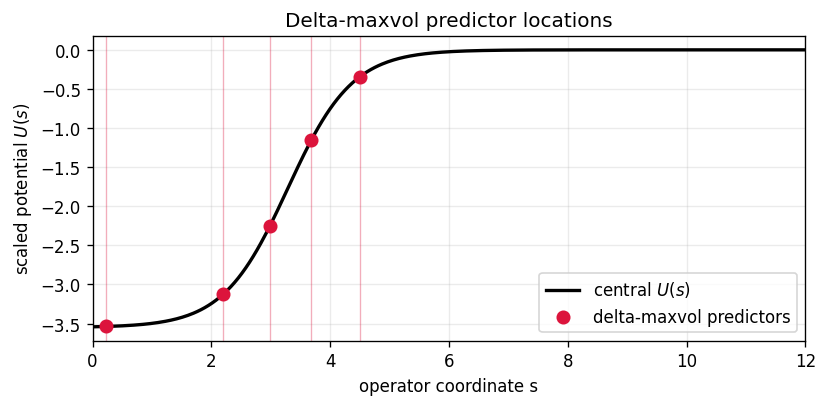

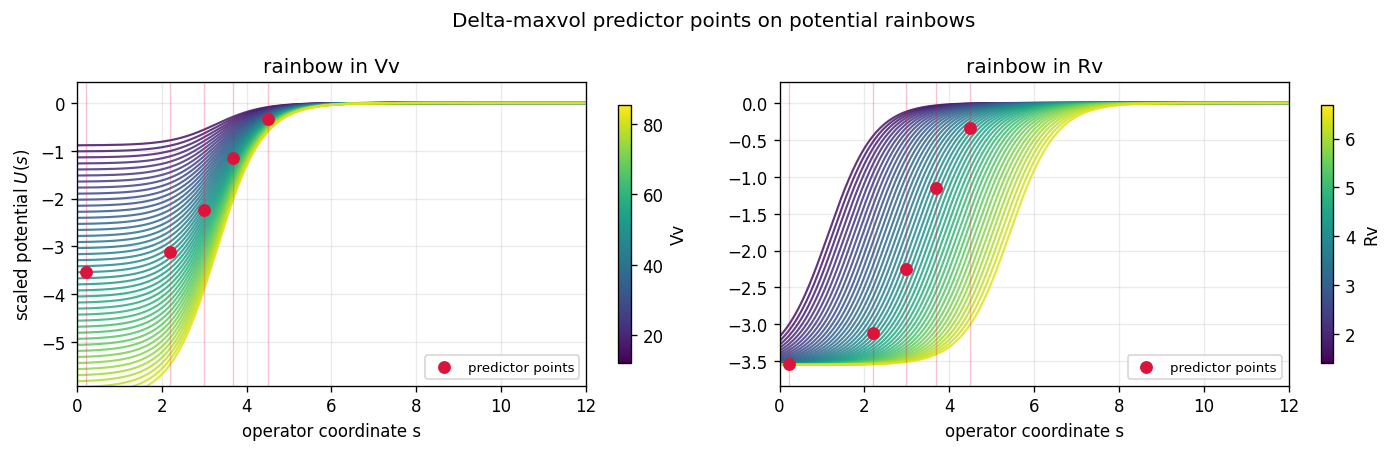

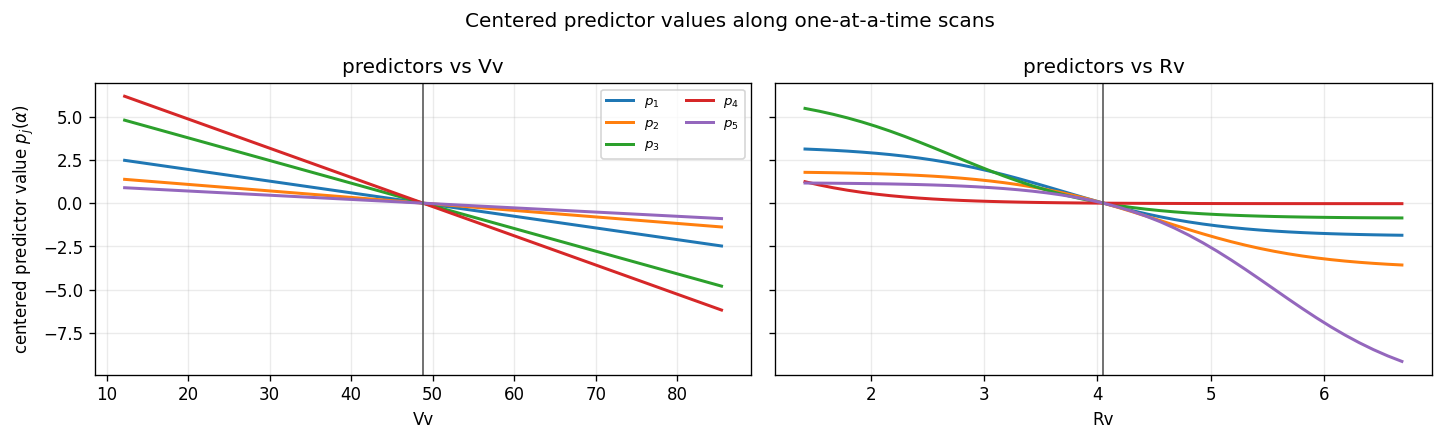

In [7]:
central_sample = broad_center.copy()
scales = broad_scales.copy()
train_samples = broad_train.copy()
test_samples = broad_scan.copy()
scan_info = broad_scan_info

rose_mp_data = core.train_multiparameter_rbe(
    name="standard ROSE Vv/Rv example",
    train_samples=train_samples,
    test_samples=test_samples,
    central_sample=central_sample,
    feature_scales=np.where(scales == 0, 1.0, scales),
    n_phi=4,
    n_U=8,
    l_max=1,
    n_mesh=800,
    real_ws_only=True,
)

mp_data = core.train_multiparameter_central_rbe(
    name="Vv/Rv predictor example",
    train_samples=train_samples,
    test_samples=test_samples,
    central_sample=central_sample,
    feature_scales=np.where(scales == 0, 1.0, scales),
    n_phi=4,
    n_U=8,
    l_max=1,
    n_mesh=800,
    real_ws_only=True,
)

interaction = mp_data.rbe.basis.solver.interaction
pack = slrom.delta_maxvol_predictor_pack(
    interaction,
    mp_data.train_alphas,
    mp_data.central_alpha,
    mp_data.rho_mesh,
    n_predictors=5,
    min_s=0.2,
)
p_train = slrom.centered_potential_predictors(interaction, mp_data.train_alphas, pack)
p_test = slrom.centered_potential_predictors(interaction, mp_data.test_alphas, pack)

p_linear_train = slrom.centered_parameter_predictors(
    train_samples[:, :2],
    central_sample[:2],
    scales[:2],
)
p_linear_test = slrom.centered_parameter_predictors(
    test_samples[:, :2],
    central_sample[:2],
    scales[:2],
)
linear_fit = slrom.fit_central_lrom("linear raw-parameter predictors", p_linear_train, mp_data.coeff_train)
coeff_linear = slrom.predict_coefficients(linear_fit, p_linear_test)
phi_linear = slrom.reconstruct_from_basis(mp_data.rbe.basis, coeff_linear)

pred_fit = slrom.fit_central_lrom("delta-maxvol potential predictors", p_train, mp_data.coeff_train)
coeff_pred = slrom.predict_coefficients(pred_fit, p_test)
phi_pred = slrom.reconstruct_from_basis(mp_data.rbe.basis, coeff_pred)

print("selected s points:", np.round(pack.s_points, 4))
print("linear fit rank:", linear_fit.rank, "parameters:", linear_fit.n_complex_parameters)
print("predictor fit rank:", pred_fit.rank, "parameters:", pred_fit.n_complex_parameters)
print("median WF error, linear LROM:", np.median(slrom.relative_l2_rows(phi_linear, mp_data.phi_basis_test)))
print("median WF error, LROM:", np.median(slrom.relative_l2_rows(phi_pred, mp_data.phi_basis_test)))
rose_mp_wf_error = slrom.relative_l2_rows(rose_mp_data.phi_rbm_test, rose_mp_data.phi_basis_test)
rose_mp_ls_phi_train = slrom.reconstruct_from_basis(rose_mp_data.rbe.basis, rose_mp_data.coeff_train)
rose_mp_ls_phi_test = slrom.reconstruct_from_basis(rose_mp_data.rbe.basis, rose_mp_data.coeff_test)
lrom_mp_ls_phi_train = slrom.reconstruct_from_basis(mp_data.rbe.basis, mp_data.coeff_train)
lrom_mp_ls_phi_test = slrom.reconstruct_from_basis(mp_data.rbe.basis, mp_data.coeff_test)
rose_mp_ls_wf_error_train = slrom.relative_l2_rows(rose_mp_ls_phi_train, rose_mp_data.phi_basis_train)
rose_mp_ls_wf_error_test = slrom.relative_l2_rows(rose_mp_ls_phi_test, rose_mp_data.phi_basis_test)
lrom_mp_ls_wf_error_train = slrom.relative_l2_rows(lrom_mp_ls_phi_train, mp_data.phi_basis_train)
lrom_mp_ls_wf_error_test = slrom.relative_l2_rows(lrom_mp_ls_phi_test, mp_data.phi_basis_test)
print("median WF error, ROSE ROM:", np.median(rose_mp_wf_error))

predictor_points_fig = plot_predictor_points_on_potential(
    interaction,
    mp_data.central_alpha,
    mp_data.rho_mesh,
    pack,
    "Delta-maxvol predictor locations",
)
predictor_points_fig.savefig(OUT / "delta_maxvol_predictor_points.png", dpi=180, bbox_inches="tight")
display(predictor_points_fig)
plt.close(predictor_points_fig)

predictor_rainbow_fig = plot_predictor_rainbows(
    interaction,
    mp_data.central_alpha,
    mp_data.rho_mesh,
    pack,
    scan_info,
    mp_data.test_alphas,
    "Delta-maxvol predictor points on potential rainbows",
)
predictor_rainbow_fig.savefig(OUT / "delta_maxvol_predictor_rainbows.png", dpi=180, bbox_inches="tight")
display(predictor_rainbow_fig)
plt.close(predictor_rainbow_fig)

predictor_values_fig = plot_predictor_values_vs_parameters(
    interaction,
    mp_data.central_alpha,
    pack,
    scan_info,
    mp_data.test_alphas,
    "Centered predictor values along one-at-a-time scans",
)
predictor_values_fig.savefig(OUT / "predictor_values_vs_vv_rv.png", dpi=180, bbox_inches="tight")
display(predictor_values_fig)
plt.close(predictor_values_fig)

The next plots look directly at the reduced coordinates along
one-at-a-time scans through the multiparameter box.  They compare the
LS target coefficients with the raw-parameter linear LROM and the
potential-predictor LROM.  This is the clean diagnostic before looking
at observables, because it separates equation-learning error from basis
truncation error.

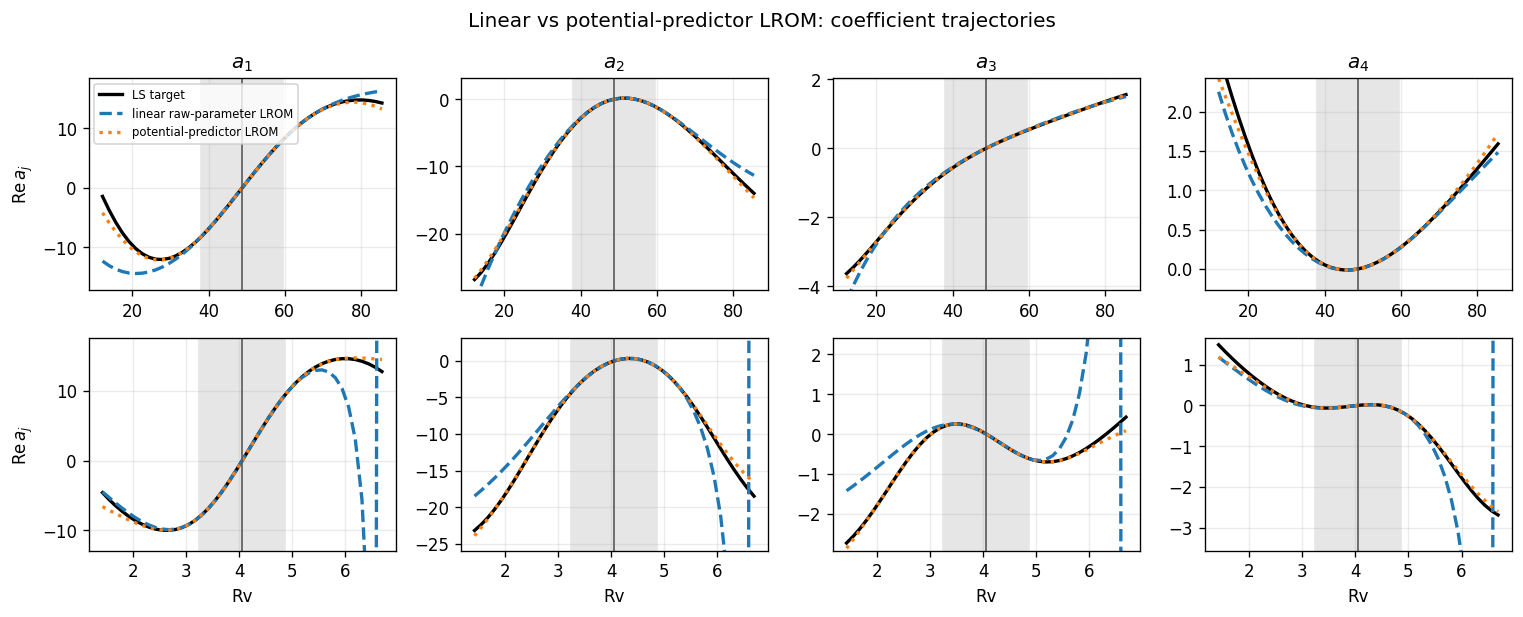

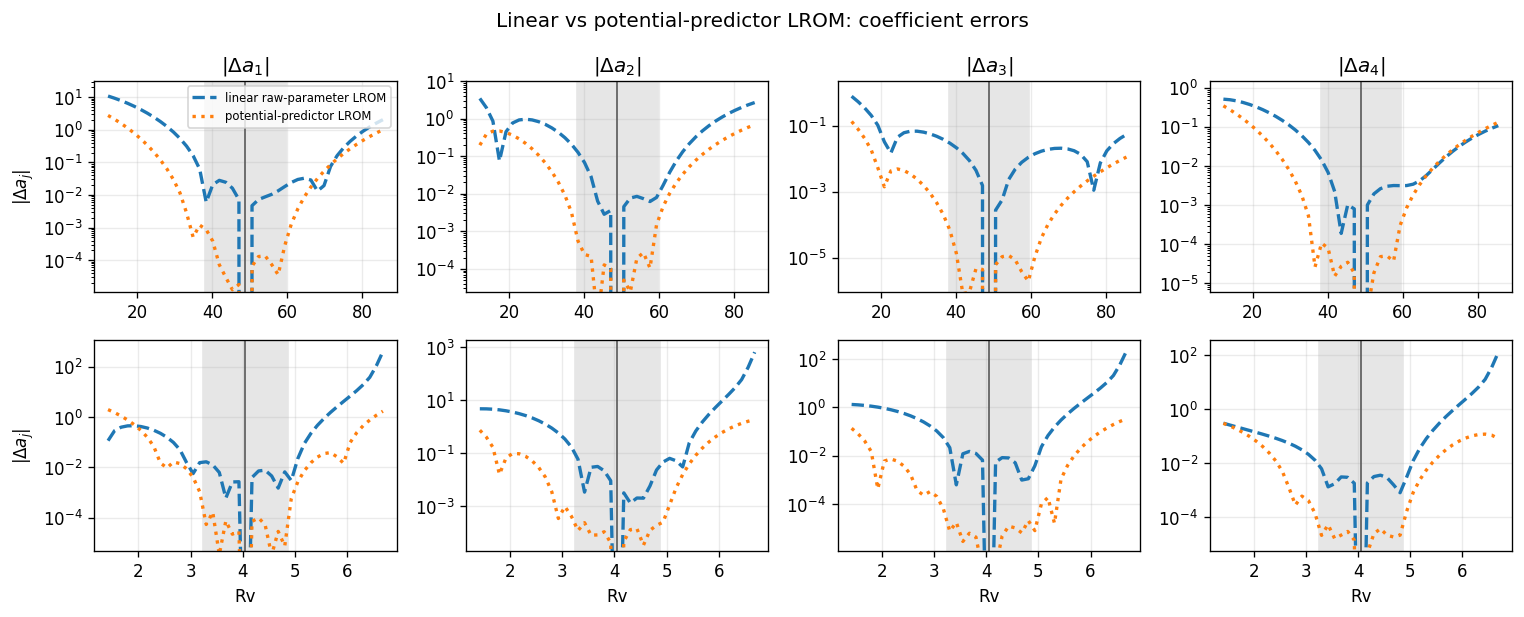

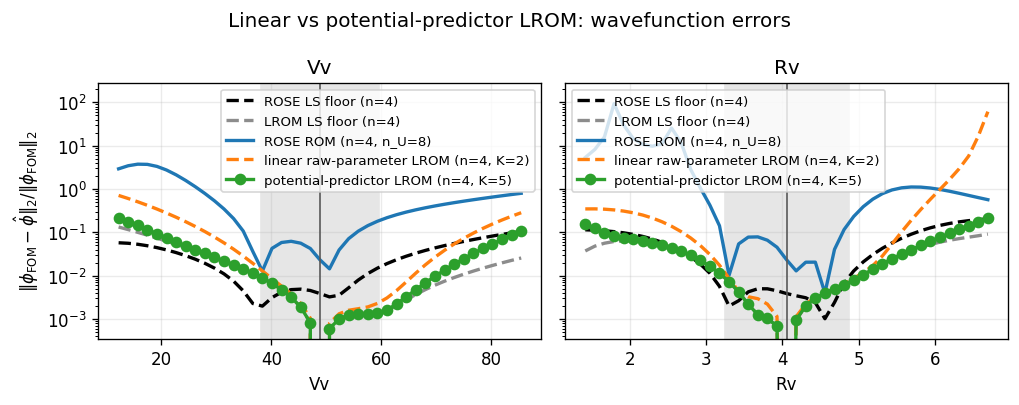

In [8]:
coeff_scan_fig, coeff_scan_err_fig = plot_scan_coefficients_and_errors(
    mp_data,
    [
        (coeff_linear, "linear raw-parameter LROM", "--"),
        (coeff_pred, "potential-predictor LROM", ":"),
    ],
    ["linear raw-parameter LROM", "potential-predictor LROM"],
    scan_info,
    "Linear vs potential-predictor LROM",
    "coefficient_determination_linear_vs_predictor",
)
display(coeff_scan_fig)
display(coeff_scan_err_fig)
wf_scan_fig = plot_scan_error_curves(
    mp_data,
    [
        (rose_mp_ls_wf_error_test, "ROSE LS floor (n=4)", "--", "black"),
        (lrom_mp_ls_wf_error_test, "LROM LS floor (n=4)", "--", "0.55"),
        (rose_mp_wf_error, "ROSE ROM (n=4, n_U=8)", "-"),
        (slrom.relative_l2_rows(phi_linear, mp_data.phi_basis_test), "linear raw-parameter LROM (n=4, K=2)", "--"),
        (slrom.relative_l2_rows(phi_pred, mp_data.phi_basis_test), f"potential-predictor LROM (n=4, K={pack.s_points.size})", "o-"),
    ],
    scan_info,
    "Linear vs potential-predictor LROM: wavefunction errors",
    "linear_vs_predictor_lrom",
)
display(wf_scan_fig)
plt.close(coeff_scan_fig)
plt.close(coeff_scan_err_fig)
plt.close(wf_scan_fig)

violin display floor: errors below 1e-05 are clipped visually only
central parameter rows removed from violin distributions
ROSE LS floor    train median=3.746e-03  test median=3.199e-02
LROM LS floor    train median=2.993e-03  test median=1.688e-02
ROSE ROM         train median=4.813e-02  test median=5.505e-01
linear LROM      train median=3.330e-03  test median=5.379e-02
predictor LROM   train median=2.993e-03  test median=2.221e-02


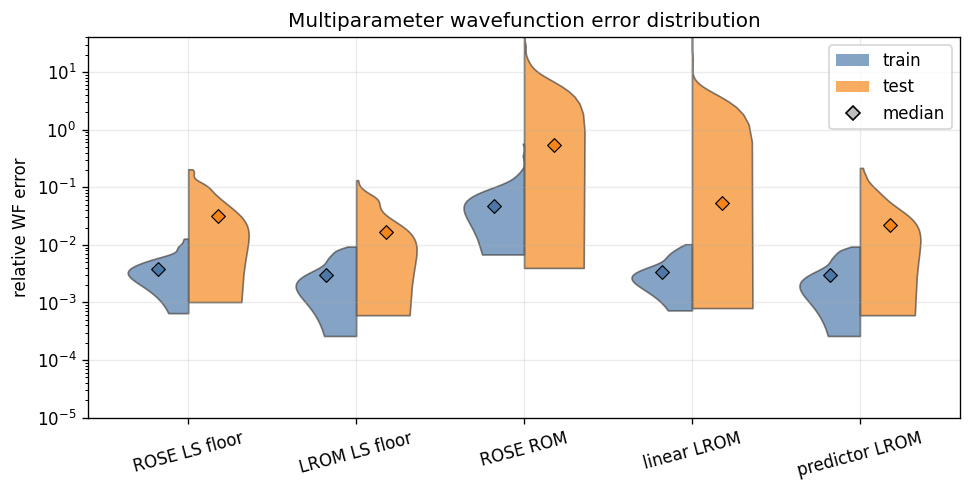

In [9]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

def split_violin(ax, values, x0, side, color, width=0.72):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return None
    parts = ax.violinplot(
        [values],
        positions=[x0],
        widths=width,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for body in parts["bodies"]:
        verts = body.get_paths()[0].vertices
        if side == "left":
            verts[:, 0] = np.minimum(verts[:, 0], x0)
        else:
            verts[:, 0] = np.maximum(verts[:, 0], x0)
        body.set_facecolor(color)
        body.set_edgecolor("0.25")
        body.set_alpha(0.68)
    return parts


def noncentral_mask(samples, center, active_indices, atol=1e-12):
    deltas = np.abs(samples[:, active_indices] - center[active_indices])
    return np.any(deltas > atol, axis=1)

coeff_linear_train = slrom.predict_coefficients(linear_fit, p_linear_train)
phi_linear_train = slrom.reconstruct_from_basis(mp_data.rbe.basis, coeff_linear_train)
coeff_pred_train = slrom.predict_coefficients(pred_fit, p_train)
phi_pred_train = slrom.reconstruct_from_basis(mp_data.rbe.basis, coeff_pred_train)

train_values = [
    rose_mp_ls_wf_error_train,
    lrom_mp_ls_wf_error_train,
    slrom.relative_l2_rows(rose_mp_data.phi_rbm_train, rose_mp_data.phi_basis_train),
    slrom.relative_l2_rows(phi_linear_train, mp_data.phi_basis_train),
    slrom.relative_l2_rows(phi_pred_train, mp_data.phi_basis_train),
]
test_values = [
    rose_mp_ls_wf_error_test,
    lrom_mp_ls_wf_error_test,
    rose_mp_wf_error,
    slrom.relative_l2_rows(phi_linear, mp_data.phi_basis_test),
    slrom.relative_l2_rows(phi_pred, mp_data.phi_basis_test),
]
labels = ["ROSE LS floor", "LROM LS floor", "ROSE ROM", "linear LROM", "predictor LROM"]
active_indices = np.array([0, 1])
train_noncentral = noncentral_mask(train_samples, central_sample, active_indices)
test_noncentral = noncentral_mask(test_samples, central_sample, active_indices)
train_values = [v[train_noncentral] for v in train_values]
test_values = [v[test_noncentral] for v in test_values]
display_floor = 1e-5
train_plot = [np.clip(v, display_floor, None) for v in train_values]
test_plot = [np.clip(v, display_floor, None) for v in test_values]

fig, ax = plt.subplots(figsize=(8.2, 4.2))
train_color = "#4C78A8"
test_color = "#F58518"
for idx, (tr, te) in enumerate(zip(train_plot, test_plot), start=1):
    split_violin(ax, tr, idx, "left", train_color)
    split_violin(ax, te, idx, "right", test_color)
    ax.scatter(idx - 0.18, np.median(tr), marker="D", s=34, color=train_color, edgecolor="black", linewidth=0.7, zorder=6)
    ax.scatter(idx + 0.18, np.median(te), marker="D", s=34, color=test_color, edgecolor="black", linewidth=0.7, zorder=6)
ax.set_xticks(range(1, len(labels) + 1), labels, rotation=15)
ax.set_yscale("log")
ax.set_ylabel("relative WF error")
ax.set_title("Multiparameter wavefunction error distribution")
top = max(float(np.quantile(v, 0.98)) for v in train_plot + test_plot)
ax.set_ylim(display_floor, max(1.0, 1.5 * top))
ax.legend(
    handles=[
        Patch(facecolor=train_color, alpha=0.68, label="train"),
        Patch(facecolor=test_color, alpha=0.68, label="test"),
        Line2D([], [], marker="D", linestyle="None", color="white", markerfacecolor="0.75", markeredgecolor="black", label="median"),
    ],
    loc="upper right",
)
print(f"violin display floor: errors below {display_floor:g} are clipped visually only")
print("central parameter rows removed from violin distributions")
for label, tr, te in zip(labels, train_values, test_values):
    print(f"{label:16s} train median={np.median(tr):.3e}  test median={np.median(te):.3e}")
fig.tight_layout()
fig.savefig(OUT / "predictor_lrom_wavefunction_violins.png", dpi=180, bbox_inches="tight")
display(fig)
plt.close(fig)